In [ ]:
np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Veri yükleme
df = pd.read_excel('preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx')  # Dosya adını değiştir
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık grade bazlı toplam sipariş
monthly_grade = df.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['Grade'].unique()

# Tahminler ve dağıtılmış sonuçlar için boş dataframe
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()

mae_list = []
mape_list = []

# 3. Her grade için SARIMAX modeli ile tahmin
for grade in grade_list:
    # 1. Grade'e ait zaman serisini hazırla
    grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')
    
    # 🔒 Model verisini 2018-01 ile 2024-12 arasında sınırla
    grade_data = grade_data.loc['2021-01':'2024-12']

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    
    # 2. ❗ Sabit ya da boş seri kontrolü
    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue  # bu grade'i atla

    # 3. SARIMAX Modeli
    try:
        model = SARIMAX(grade_ts, order=(1,0,0), seasonal_order=(0,0,0,0))
        results = model.fit(disp=False)
    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    # 4. Tahmin (örnek: 3 ay ileri)
    forecast = results.get_forecast(steps=3)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index
    
    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index
    
    # 🔍 Gerçek 2025 verisini al
    full_grade_data = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')
    test_data = full_grade_data.loc['2025-01':'2025-03']['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    common_months = test_data.index.intersection(forecast_index)

    print(common_months)
    if len(common_months) > 0:
        actual = test_data.loc[common_months]
        predicted = forecast_values.loc[common_months]

        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)

        mae_list.append({'Grade': grade, 'MAE_Model': mae})
        mape_list.append({'Grade': grade, 'MAPE_Model': mape})

        print(f"\n📈 Grade '{grade}' için MODEL tahmini:")
        print(f"Gerçek: {actual.values}, Tahmin: {predicted.values}")
        print(f"MAE: {mae:.2f}, MAPE: {mape:.2%}")

    # 5. Forecast DataFrame'e ekle
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'Grade': grade,
        'Forecast_TON': forecast_values.values
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)
    
    temp_forecast_train = pd.DataFrame({
        'Month': train_forecast_index,
        'Grade': grade,
        'Forecast_TON': train_forecast.values
    })
    train_forecast_df = pd.concat([train_forecast_df, temp_forecast_train], ignore_index=True)
    
    # 6. Disaggregation (her tahmin edilen ayı specGroupId'lere dağıt)
    for month in forecast_index:
        # Önce o grade'in geçmiş aynı aya ait oranlarını bul
        past_months = df[(df['Grade'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()
        

        # Eğer ay bazlı veri yoksa: tüm geçmişi fallback olarak kullan
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
            past_months = df[df['Grade'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        # Hâlâ yoksa atla
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[month]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'Grade': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
        
        

        # 💡 SpecGroupId bazlı gerçek değerlerle kıyasla
        actual_df = df[(df['Month'] == month) & (df['Grade'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Month'] == month) &
            (disaggregated_df['Grade'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)

        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            mae_spec = mean_absolute_error(actual_vals, pred_vals)
            mape_spec = mean_absolute_percentage_error(actual_vals, pred_vals)

            # 🔁 Sonuçları listeye ekle
            for spec_id in common_index:
                disagg_metrics = {
                    'Grade': grade,
                    'Month': month,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)

                
        """   
        # 6. Disaggregation for train

                
        for forecast_month in train_forecast_index:
            # Try to get proportions based on same calendar month in history
            historical_month_data = df[(df['Grade'] == grade) & 
                                            (df['Month'].dt.month == forecast_month.month)]

            monthly_group_totals = historical_month_data.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            monthly_total_sum = monthly_group_totals.sum()
            spec_30_total = monthly_group_totals.get(30, 0)
            print(forecast_month,spec_30_total)

            # If no month-based data, fallback to all historical data for the grade
            if monthly_total_sum == 0:
                print(f"{grade} için {forecast_month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
                historical_month_data = df[df['Grade'] == grade]
                monthly_group_totals = historical_month_data.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
                monthly_total_sum = monthly_group_totals.sum()

            # Still no data? Skip.
            if monthly_total_sum == 0:
                print(f"{grade} için {forecast_month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
                continue

            spec_group_proportions = monthly_group_totals / monthly_total_sum
            disaggregated_values = spec_group_proportions * train_forecast[forecast_month]


            spec_30 = spec_group_proportions.get(30, 0)
            print("specgroupproop",spec_30)
            print("alttaki",train_forecast)

            for spec_group_id, forecast_ton in disaggregated_values.items():
                disaggregated_forecast_df = pd.concat([disaggregated_forecast_df, pd.DataFrame({
                    'Month': [forecast_month],
                    'Grade': [grade],
                    'SpecGroupId': [spec_group_id],
                    'Forecast_TON': [forecast_ton]
                })])
            
            
            
            """
    

# İstersen Excel'e aktar:
disaggregated_df.to_excel("disaggregated_forecast.xlsx", index=False)


In [ ]:
from sklearn.metrics import mean_squared_error

# 🎯 Grade bazlı performans metriklerini hesapla
grade_metrics = []

# forecast_df: grade bazlı 3 aylık tahminlerin olduğu dataframe
# monthly_grade: gerçek değerlerin olduğu dataframe

for grade in forecast_df['Grade'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['Grade'] == grade].set_index('Month')['Forecast_TON']
    
    # Gerçek veriler
    actual_series = monthly_grade[monthly_grade['Grade'] == grade].set_index('Month')['Sipariş Mik. (TON)']
    
    # Ortak aylar
    common_months = pred_series.index.intersection(actual_series.index)
    
    if len(common_months) == 0:
        continue

    y_true = actual_series.loc[common_months]
    y_pred = pred_series.loc[common_months]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'Grade': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 Grade Bazlı Tahmin Performansı:")
print(grade_metrics_df)

# Excel'e kaydetmek istersen:
# grade_metrics_df.to_excel("grade_metrics_summary.xlsx", index=False)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 🎯 Tüm Grade'ler için genel hata metrikleri
# forecast_df: tahminler (2025-01 ~ 2025-03)
# monthly_grade: gerçek değerler

# Gerçek veriyi 2025-01 ile 2025-03 arasından alalım
actual_all = monthly_grade[
    (monthly_grade['Month'] >= '2025-01') & 
    (monthly_grade['Month'] <= '2025-03')
]

# Tahmin edilen veriler zaten forecast_df içinde (her Grade için)
merged_all = pd.merge(
    actual_all, 
    forecast_df, 
    on=['Month', 'Grade'], 
    how='inner'
)

# Boş varsa at
merged_all.dropna(subset=['Sipariş Mik. (TON)', 'Forecast_TON'], inplace=True)

# Gerçek ve tahmin serileri
y_true_all = merged_all['Sipariş Mik. (TON)']
y_pred_all = merged_all['Forecast_TON']

# Hata metrikleri
mae_all = mean_absolute_error(y_true_all, y_pred_all)
mape_all = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
smape_all = 100 * np.mean(2 * np.abs(y_pred_all - y_true_all) / (np.abs(y_true_all) + np.abs(y_pred_all)))
wmape_all = 100 * np.sum(np.abs(y_pred_all - y_true_all)) / np.sum(np.abs(y_true_all))

# 📢 Sonuçları yazdır
print("\n📦 Tüm Grade'ler için TOPLAM tahmin performansı:")
print(f"MAE   : {mae_all:.2f}")
print(f"MAPE  : {mape_all:.2f}%")
print(f"sMAPE : {smape_all:.2f}%")
print(f"wMAPE : {wmape_all:.2f}%")
print(f"RMSE  : {rmse_all:.2f}")


In [ ]:
import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2025-01', '2025-02', '2025-03']

for month in target_months:
    print(f"⏳ {month} ayı için grafik hazırlanıyor...")

    forecast_m = forecast_df[forecast_df['Month'] == month]
    actual_m = monthly_grade[monthly_grade['Month'] == month]

    # Verileri aynı forma sok
    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6))
    plt.title(f"{month} - Grade Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()



In [ ]:
import matplotlib.pyplot as plt

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = [ '30', '941', '650']  # buraya ilgilendiğin ID'leri yaz

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    
    # 🔗 İki veri setini birleştir
    merged = pd.concat([actual_series, forecast_series], axis=1)

    # 📈 Grafik
    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Forecast'], label='Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = ['30', '941', '650']

# Sonuçları saklamak için boş DataFrame oluştur
metrics_df = pd.DataFrame(columns=['SpecGroupId', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    # 🔗 İki veri setini birleştir ve NaN değerleri kaldır
    merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

    # 📌 Hata metriklerini hesapla
    mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
    mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
    rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))

    # sMAPE hesapla
    smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) / (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))

    # wMAPE hesapla
    wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

    # Sonuçları DataFrame'e ekle
    metrics_df = metrics_df.append({'SpecGroupId': spec_id,
                                    'MAE': mae,
                                    'MAPE (%)': mape,
                                    'sMAPE (%)': smape,
                                    'wMAPE (%)': wmape,
                                    'RMSE': rmse}, ignore_index=True)

# 📊 Sonuçları göster
print(metrics_df)



In [ ]:
# Gerekli kütüphaneler
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# 🔗 Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den büyük olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > -0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# 🎯 Metrikleri hesapla
mae = mean_absolute_error(filtered_merged['Actual'], filtered_merged['Forecast'])
rmse = np.sqrt(mean_squared_error(filtered_merged['Actual'], filtered_merged['Forecast']))
mape = mean_absolute_percentage_error(filtered_merged['Actual'], filtered_merged['Forecast']) * 100
smape = 100 * np.mean(2 * np.abs(filtered_merged['Forecast'] - filtered_merged['Actual']) / 
                      (np.abs(filtered_merged['Forecast']) + np.abs(filtered_merged['Actual'])))
wmape = 100 * np.sum(np.abs(filtered_merged['Forecast'] - filtered_merged['Actual'])) / np.sum(np.abs(filtered_merged['Actual']))

# Sonuçları yazdır
print(f"Gerçek değeri 0.1'den büyük olanlar için:\n"
      f"MAE   : {mae:.2f}\n"
      f"RMSE  : {rmse:.2f}\n"
      f"MAPE  : {mape:.2f}%\n"
      f"sMAPE : {smape:.2f}%\n"
      f"wMAPE : {wmape:.2f}%")



In [ ]:
results.summary()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den yüksek olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > 0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# SARIMAX Modelini çalıştır
model = SARIMAX(filtered_merged['Actual'], order=(1,0,0))
result = model.fit()

# R² Hesapla
predictions = result.fittedvalues
r2 = r2_score(filtered_merged['Actual'], predictions)

# Parametrelerin anlamlılık tablosunu hazırla
params_summary = pd.DataFrame({
    'Coefficient': result.params,
    'Std_Error': result.bse,
    'p-value': result.pvalues,
    'Significant': result.pvalues < 0.05
})

# Sonuçları yazdır
print(f"R²: {r2:.4f}")
print("\nParametrelerin Anlamlılık Tablosu:\n", params_summary)

In [61]:
import pandas as pd

# Gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']]\
    .groupby(['Month', 'SpecGroupId', 'Grade'])\
    .sum().reset_index()

actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']]\
    .groupby(['Month', 'SpecGroupId'])\
    .sum().reset_index()

forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Gerçek ve Tahmin verilerini birleştir
merged_all = pd.merge(actual_series_all, forecast_series_all, 
                      on=['Month', 'SpecGroupId'], 
                      how='left').dropna()

# Sonucu Excel'e kaydet
merged_all.to_excel('actual_forecast_with_grade_month_specgroup.xlsx', index=False)



⏳ 2019-01 ayı için grafik hazırlanıyor...
⚠️ 2019-01 için hem tahmin hem gerçek veri yok.
⏳ 2022-07 ayı için grafik hazırlanıyor...


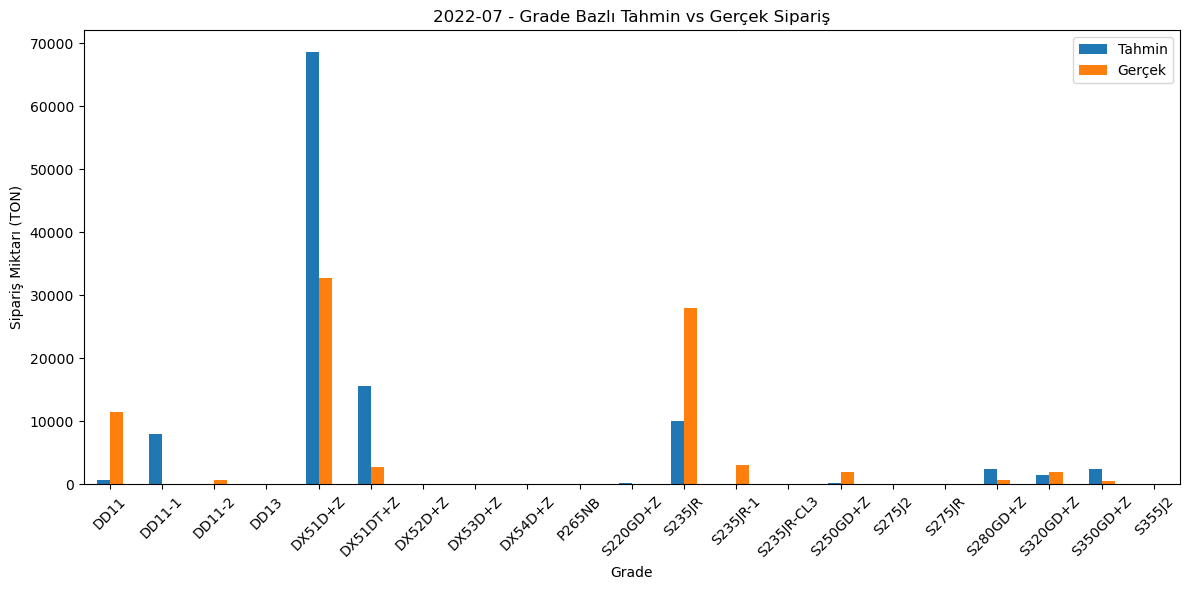

⏳ 2023-03 ayı için grafik hazırlanıyor...


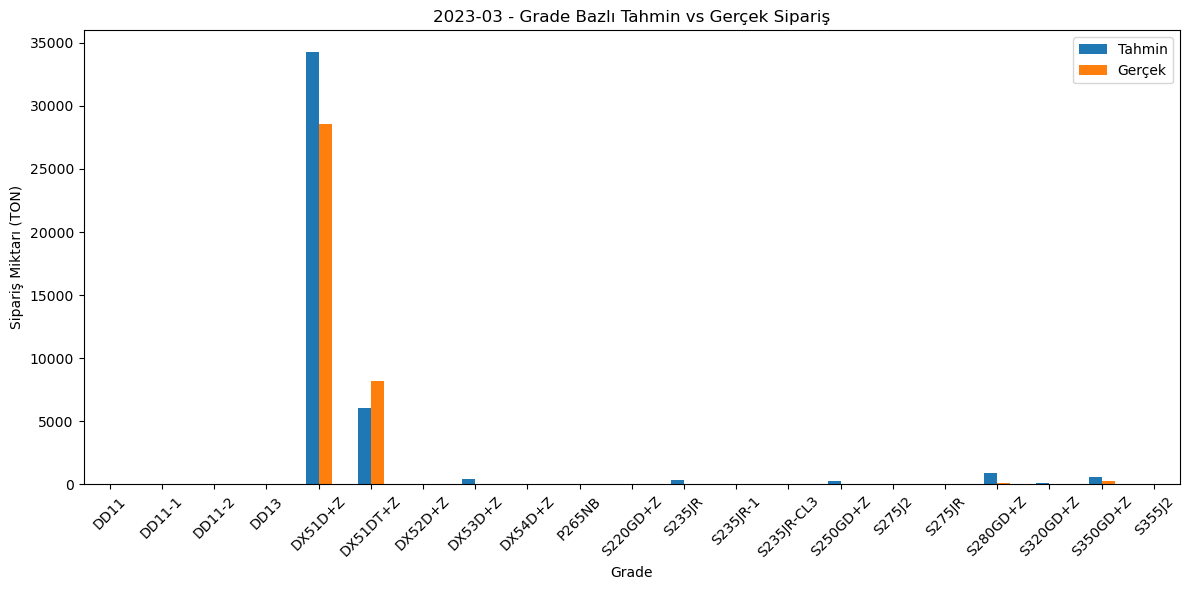

In [42]:
#OVERFIT TEST

import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2019-01', '2022-07', '2023-03']

for month in target_months:
    print(f"⏳ {month} ayı için grafik hazırlanıyor...")

    forecast_m = train_forecast_df[train_forecast_df['Month'] == month]
    actual_m = monthly_grade[monthly_grade['Month'] == month]

    # Verileri aynı forma sok
    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6))
    plt.title(f"{month} - Grade Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()


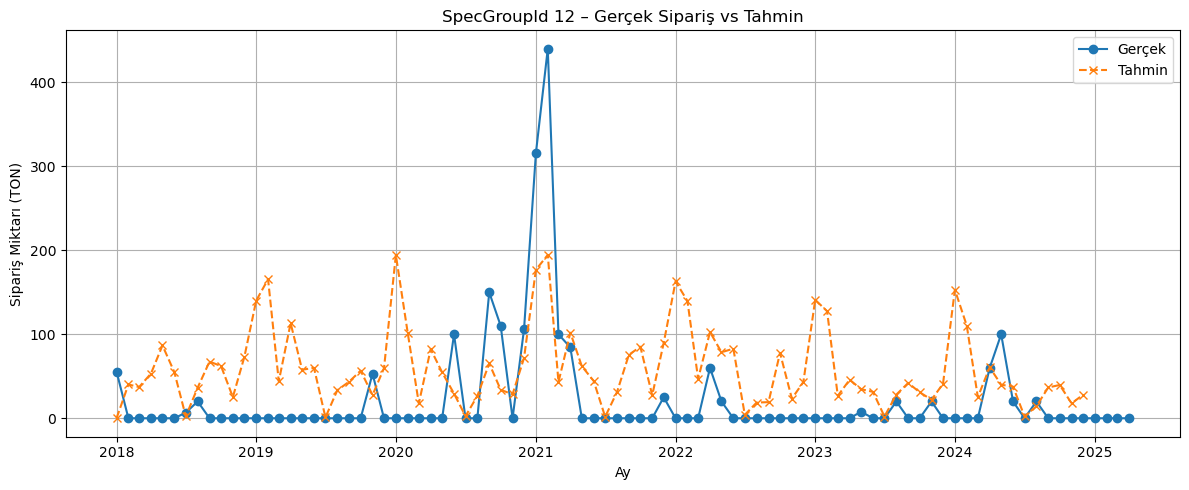

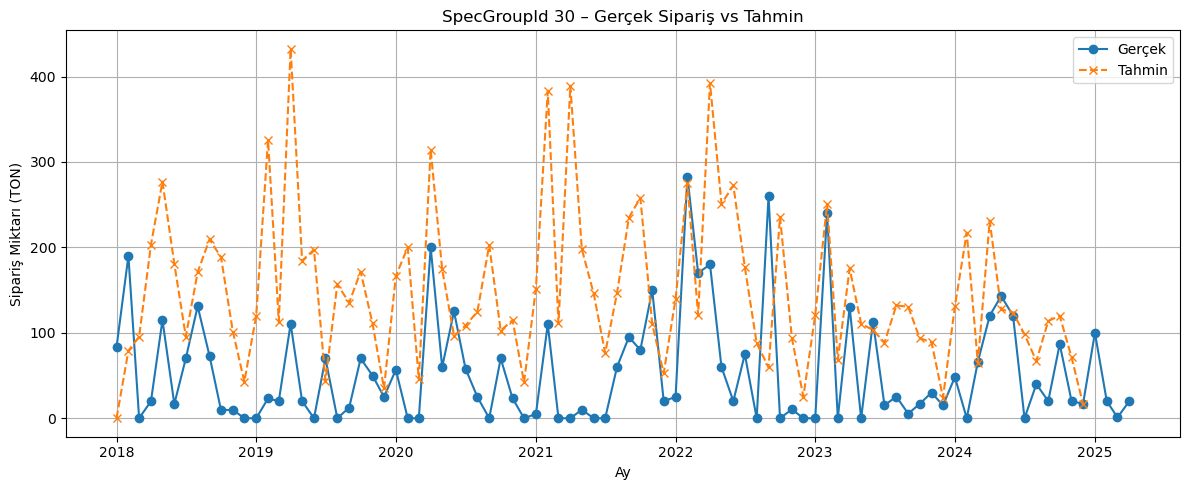

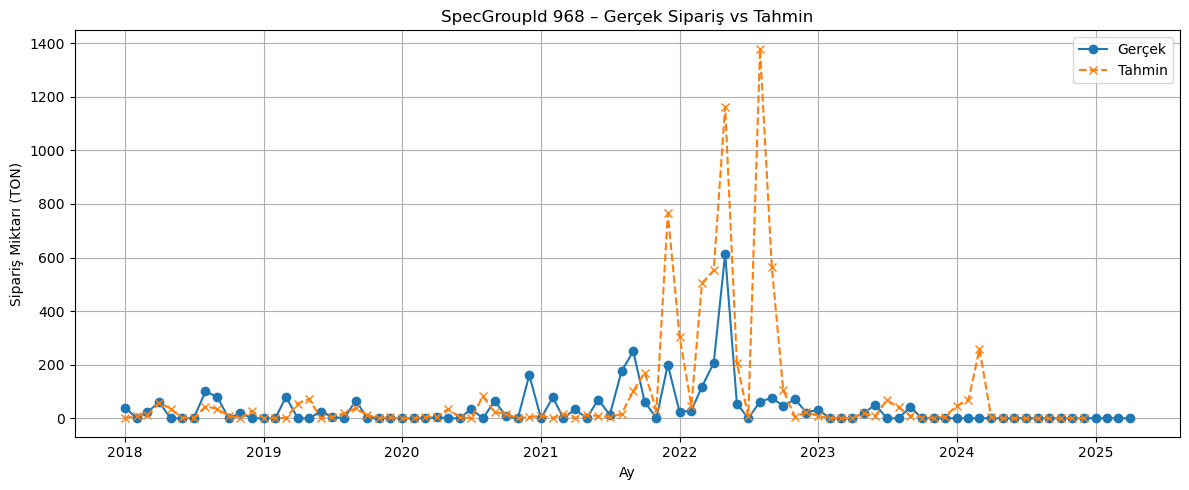

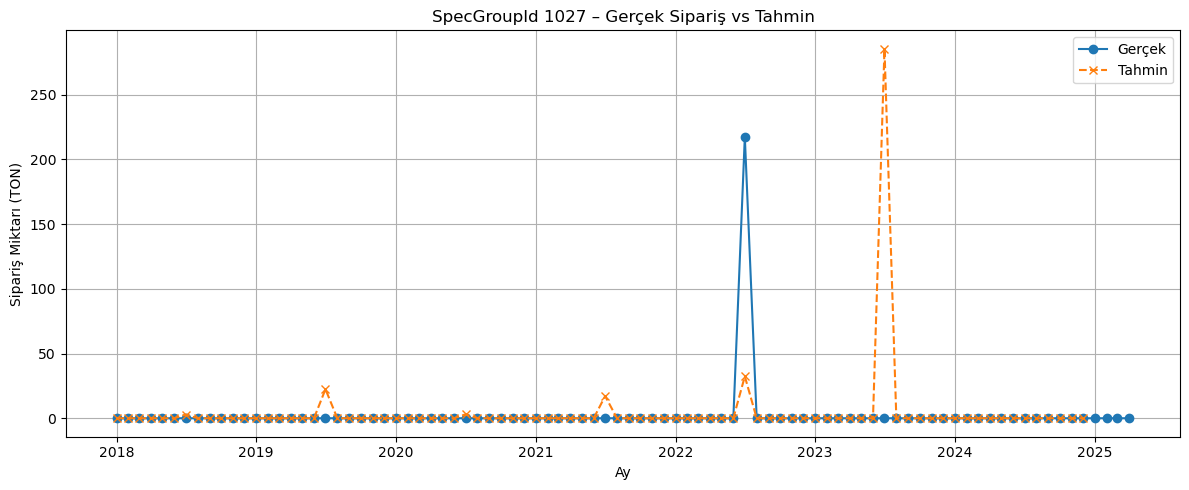

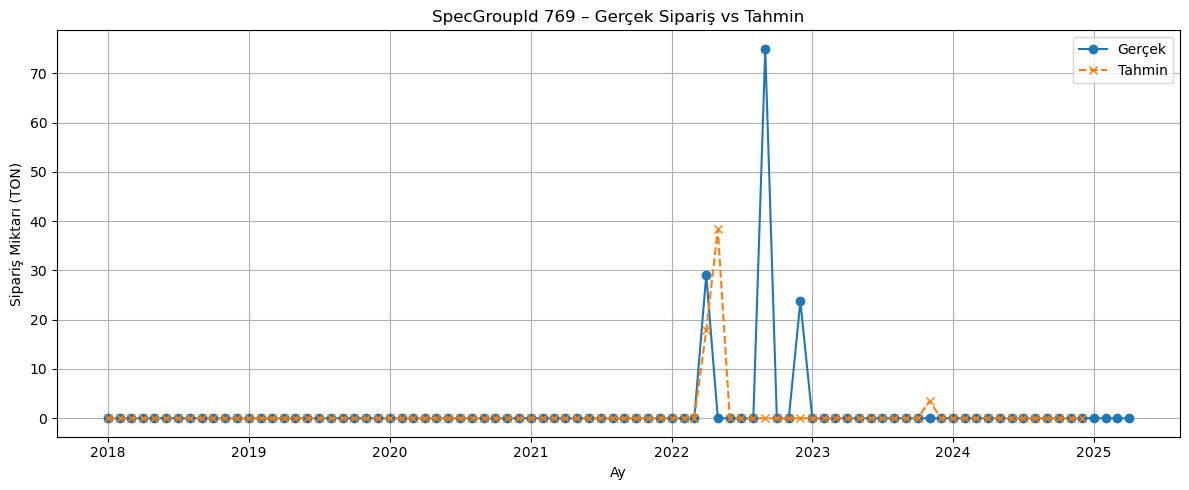

In [9]:
import matplotlib.pyplot as plt

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = [ '12', '30', '968','1027', '769']  # buraya ilgilendiğin ID'leri yaz
for spec_id in selected_spec_ids:
        # 🔹 Gerçek veriler (geçmiş)
        actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
        actual_series = actual_series.groupby('Month').sum().sort_index()
        actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

        # 🔹 Tahmin verileri (disaggregated)
        forecast_series = disaggregated_forecast_df[disaggregated_forecast_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
        forecast_series = forecast_series.groupby('Month').sum().sort_index()
        forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)


        # 🔗 İki veri setini birleştir
        merged = pd.concat([actual_series, forecast_series], axis=1)

        # 📈 Grafik
        plt.figure(figsize=(12, 5))
        plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
        plt.plot(merged.index, merged['Forecast'], label='Tahmin', linestyle='--', marker='x')
        plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Tahmin")
        plt.xlabel("Ay")
        plt.ylabel("Sipariş Miktarı (TON)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()